In [1]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pathlib import Path
import sys
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.constants import (
    PREDICTOR_COLS, 
    DEMOGRAPHIC_PREDICTORS, 
    PROPERTY_PREDICTORS,
    TRANSIT_PREDICTORS, 
    TRANSIT_MODEL_PREDICTORS, 
    IMAGERY_PREDICTORS, 
    ROADWAY_PREDICTORS,
    ACS_TRANSIT_PREDICTORS,
    TARGET_CATEGORIES,
    ZERO_FILL,
    MEDIAN_FILL,
    DEMOGRAPHIC_MODEL_PREDICTORS, 
    PROPERTY_MODEL_PREDICTORS,
    TRANSIT_MODEL_PREDICTORS, 
    ACS_TRANSIT_MODEL_PREDICTORS
)
from regression_modelling.models.dataset import load_pooled_table, target_pool, property_cities
from regression_modelling.data_wrangling.features import assemble_features
sns.set_theme(style="whitegrid")

In [ ]:
import pandas as pd
import pyreadstat
import re
import numpy as np
from gcsfs import GCSFileSystem
import tempfile 

#Path to GCS buckets
fs = GCSFileSystem(project='clgx-gis-app-dev-06e3', token='google_default')
gcs_path = "gs://geospatial-projects/location_inc"

#program to read sav
def read_sav_from_gcs(gcs_path: str, fs: GCSFileSystem) -> pd.DataFrame:
    with fs.open(gcs_path, "rb") as gcs_file:
        # Write the content to a temporary file
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.write(gcs_file.read())
            temp_file.flush()
            temp_file.close()
            # Read the .sav file using pyreadstat
            df, meta = pyreadstat.read_sav(temp_file.name)  
    return df, meta

In [2]:
# Ingesting data for all POC cities
ALL_CITIES = property_cities()           # all 20: every source carries property crime
WTOTAL_CITIES = target_pool("wtotal", verbose=False)    # 10: only these geolocate violent crime

pool = load_pooled_table(cities=ALL_CITIES)          # same population filters the models use
pool["in_wtotal"] = pool["city"].isin(WTOTAL_CITIES)

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  sacramento          366 BGs
  san_francisco       679 BGs
  pittsburgh          317 BGs
  kansas_city         473 BGs
  columbus            637 BGs
  jacksonville        550 BGs
  detroit             622 BGs
  philadelphia       1338 BGs
  milwaukee           567 BGs
  baltimore           618 BGs
  dc                  571 BGs
  oakland             353 BGs
  new_york           6712 BGs
  dallas              869 BGs
  denver              572 BGs
  las_vegas           439 BGs
  seattle             537 BGs
  pooled            20439 BGs across 20 cities
  dropped 307 zero/NaN-pop BGs -> 20132 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 78 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 20054 remain


In [3]:
# Cities by block groups in ascending order
pool.groupby("city").size().sort_values()

city
pittsburgh        306
oakland           352
sacramento        366
atlanta           424
las_vegas         439
kansas_city       469
seattle           537
jacksonville      550
dc                562
denver            564
milwaukee         567
detroit           605
baltimore         618
columbus          637
san_francisco     676
dallas            861
philadelphia     1297
houston          1627
chicago          2159
new_york         6438
dtype: int64

In [4]:
# Same tables with the filters turned off, so we can see what the models drop
raw = load_pooled_table(cities=ALL_CITIES, drop_zero_pop=False, daytime_pop_floor=0)

by_city = pool.groupby("city")

inv = pd.DataFrame({
    "bgs_raw":       raw.groupby("city").size(),
    "bgs_kept":      by_city.size(),
    "population":    by_city["population"].sum(),
    "median_bg_pop": by_city["population"].median(),
})
inv["pct_dropped"] = (1 - inv["bgs_kept"] / inv["bgs_raw"]).mul(100).round(1)
inv["pct_of_pool"] = (inv["bgs_kept"] / inv["bgs_kept"].sum()).mul(100).round(1)
inv["in_wtotal"]   = inv.index.isin(WTOTAL_CITIES)
inv.sort_values("bgs_kept", ascending=False)

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  sacramento          366 BGs
  san_francisco       679 BGs
  pittsburgh          317 BGs
  kansas_city         473 BGs
  columbus            637 BGs
  jacksonville        550 BGs
  detroit             622 BGs
  philadelphia       1338 BGs
  milwaukee           567 BGs
  baltimore           618 BGs
  dc                  571 BGs
  oakland             353 BGs
  new_york           6712 BGs
  dallas              869 BGs
  denver              572 BGs
  las_vegas           439 BGs
  seattle             537 BGs
  pooled            20439 BGs across 20 cities


,bgs_raw,bgs_kept,population,median_bg_pop,pct_dropped,pct_of_pool,in_wtotal
city,,,,,,,
new_york,6712,6438,8536270.0,1242.5,4.1,32.1,False
chicago,2164,2159,2724444.0,1170.0,0.2,10.8,True
houston,1629,1627,2431034.0,1395.0,0.1,8.1,True
philadelphia,1338,1297,1576867.0,1110.0,3.1,6.5,True
dallas,869,861,1360442.0,1479.0,0.9,4.3,False
san_francisco,679,676,826717.0,1159.0,0.4,3.4,False
columbus,637,637,873004.0,1181.0,0.0,3.2,False
baltimore,618,618,570721.0,852.0,0.0,3.1,True
detroit,622,605,646237.0,1020.0,2.7,3.0,True


In [ ]:
#Spot checked above from FBI published populations: 
"""
#open offenses by city_df
year = 2025
city_file = f"Table_8_Offenses_Known_to_Law_Enforcement_by_State_by_City_{year}.xlsx"
city_df=pd.read_excel(f"{gcs_path}/crime/{year}/{city_file}",header=3)
#check population by city name
lookup = city_df[city_df['City'].notna()]
lookup.loc[lookup['City'].str.contains("Las Vegas"),['City','State','Population']].sort_values(by='Population', ascending = False)
"""
#Las Vegas looks like it could be missing some areas. The rest I checked look right

#City	                                    State	Population
# Las Vegas Metropolitan Police Department	Nevada	1712136.0

In [5]:
# Helper to examine summary stats
def target_summary(df, col):
    g = df.groupby("city")[col]
    s = pd.DataFrame({
        "median": g.median(),
        "p10": g.quantile(.10), 
        "p25": g.quantile(.25),
        "p75": g.quantile(.75), 
        "p90": g.quantile(.90),
        "p99": g.quantile(.99),

    })
    s["iqr"] = s["p75"] - s["p25"]
    s["p90_p10"] = s["p90"] / s["p10"]          # within-city spread, unit-free
    s["p99_p90"] = s["p99"] / s["p90"]          # within-city DANGEROUS spread! 
    s["pct_zero"] = g.apply(lambda x: (x == 0).mean() * 100)
    return s.sort_values("median", ascending=False).round(1)

In [6]:
# Define the target for which we want to examine summary data
targets = {"wtotal_rate": pool[pool["in_wtotal"]], "wprop_rate": pool}
summaries = {t: target_summary(df, t) for t, df in targets.items()}

for t, s in summaries.items():
    print(t); display(s)

wtotal_rate


,median,p10,p25,p75,p90,p99,iqr,p90_p10,p99_p90,pct_zero
city,,,,,,,,,,
detroit,64.9,24.0,39.8,105.3,177.3,397.0,65.5,7.4,2.2,0.2
baltimore,55.5,17.3,31.1,108.9,186.9,700.7,77.9,10.8,3.7,0.0
milwaukee,48.9,10.3,23.0,98.5,169.9,331.7,75.5,16.6,2.0,0.0
kansas_city,47.6,6.4,18.4,98.8,191.6,774.1,80.3,29.8,4.0,0.2
oakland,40.9,14.9,24.5,69.0,103.1,316.5,44.5,6.9,3.1,0.0
philadelphia,35.4,13.3,21.5,64.1,117.7,1459.7,42.6,8.9,12.4,0.1
houston,34.7,5.7,15.2,67.7,110.2,281.8,52.5,19.4,2.6,2.7
atlanta,33.0,4.2,13.2,64.0,117.5,301.8,50.9,28.0,2.6,0.7
chicago,28.9,7.3,13.6,64.3,121.5,289.9,50.7,16.7,2.4,0.2


wprop_rate


,median,p10,p25,p75,p90,p99,iqr,p90_p10,p99_p90,pct_zero
city,,,,,,,,,,
detroit,52.4,22.9,36.3,70.7,93.6,337.9,34.4,4.1,3.6,0.2
oakland,47.0,21.1,34.6,66.2,112.8,369.4,31.6,5.4,3.3,0.0
seattle,41.4,16.7,26.1,72.1,104.7,230.2,46.0,6.3,2.2,0.2
kansas_city,41.1,6.9,18.2,68.3,116.7,925.0,50.1,16.9,7.9,0.2
baltimore,39.9,17.0,25.4,58.3,81.2,723.3,32.9,4.8,8.9,0.0
denver,34.0,11.2,20.2,53.9,84.2,293.1,33.7,7.5,3.5,0.5
philadelphia,32.9,16.6,23.3,48.3,80.2,1439.1,25.0,4.8,17.9,0.2
milwaukee,30.4,9.8,17.9,45.9,63.5,140.9,28.0,6.5,2.2,0.4
houston,27.1,4.9,13.1,47.6,78.0,213.4,34.6,15.8,2.7,3.1


**Open Questions:**
1. Recheck DC data - numbers seem too low
2. What about Boston data? Portal seems to be working

In [ ]:
#spot checks 
"""
#get agency FBI reporting
agency_df, meta = read_sav_from_gcs(f"{gcs_path}/crime/2025/ucr_agency.sav", fs)

#created weighted rates
crimes = ['violent','murder','rape','robbery','assault','property','burglary','larceny','mvt']
for c in crimes:
    agency_df[f'{c}_rate'] = 1000*agency_df[c] / agency_df['Population']
vw = agency_df['murder_rate']/.07 + agency_df['rape_rate']/.46+agency_df['robbery_rate']/2.16+agency_df['assault_rate']/4.89
pw = (agency_df['burglary_rate']/2.29)+(agency_df['larceny_rate']/12.72)+(agency_df['mvt_rate']/2.59)
agency_df['wprop_rate'] = (2.29+12.72+2.59) * pw /3
agency_df['wtotal_rate'] = (2.29+12.72+2.59+.07+.46+2.16+4.89) * (pw+vw) /7

#spot checks
agency_df[agency_df['akey'].str.contains("WASHINGTON_DC")][['akey','wtotal_rate','wprop_rate','violent_rate','property_rate']]
"""
#akey	        wtotal_rate	wprop_rate	violent_rate	property_rate
#WASHINGTON_DC	36.86755	29.955161	7.467797	    30.701584
#DETROIT_MI	    62.305324	48.662071	16.491346	    38.822403
#NEWYORK_NY	    21.364713	16.929355	6.565021	    22.729364
#CHICAGO_IL	    34.391875	30.328558	4.204401	    29.424177


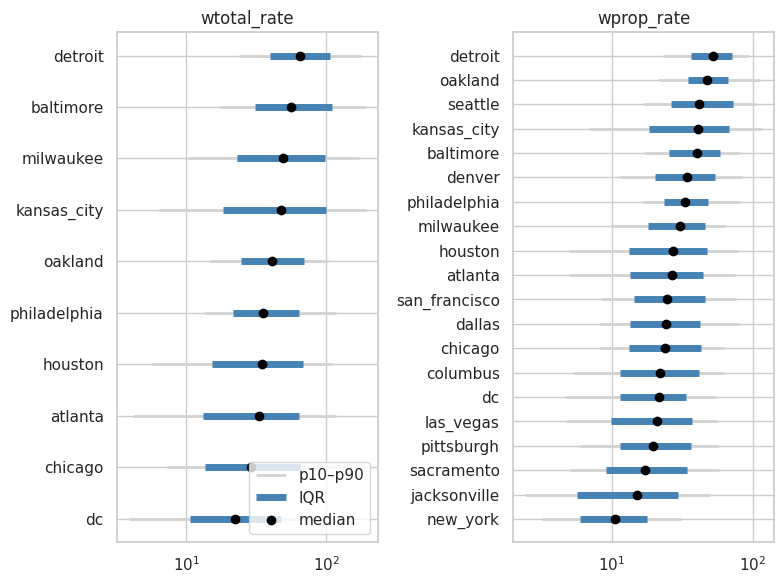

In [7]:
# Range plot
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
for ax, (t, s) in zip(axes, summaries.items()):
    s = s.sort_values("median")
    y = np.arange(len(s))
    ax.hlines(y, s["p10"], s["p90"], color="lightgray", lw=2, label="p10–p90")
    ax.hlines(y, s["p25"], s["p75"], color="steelblue", lw=5, label="IQR")
    ax.plot(s["median"], y, "o", color="black", label="median")
    ax.set_yticks(y, s.index); ax.set_xscale("log"); ax.set_title(t)
axes[0].legend(loc="lower right")
fig.tight_layout(); plt.show()

**Spatial Correlation:**
* Global Moran's I gives one number per city: how similar each block group is to its 8 nearest neighbours (0 = random, 1 = perfectly clustered).
* Local Moran (LISA) tags each block group as a hotspot (High-High), coldspot (Low-Low), or outlier.
    * Use own value and value of x neighbors as the two axes
    * For each axis, assign high / low label using city mean as the reference point
    * So say city mean of Chicago is 24. A block group with crime rate of 25 would be high on one axis. If the average of its x neighbors is also > 24, it would be labeled high-high 
* Both run on  log1p(rate) , because a few extreme block groups would otherwise dominate Moran's I.

In [8]:
import io, contextlib, warnings
from libpysal.weights import KNN
from esda.moran import Moran_Local
from regression_modelling.models.inference import residual_spatial

warnings.filterwarnings("ignore", message=".*geographic CRS.*")
warnings.filterwarnings("ignore", message=".*not fully connected.*")

def city_moran(pool, city, target, k=8):
    """Geometry + global Moran's I for log1p(target) in one city."""
    df = pool[pool["city"] == city]
    with contextlib.redirect_stdout(io.StringIO()):          # silence loader prints
        gdf, mi = residual_spatial(city, df["geoid"], np.log1p(df[target]), k=k)
    return gdf.rename(columns={"resid": target}), mi

In [9]:
# Producing the Global Moran's I for each city
rows, geo = [], {}
for city in ALL_CITIES:
    for target in ["wtotal_rate", "wprop_rate"]:
        if target == "wtotal_rate" and city not in WTOTAL_CITIES:
            continue
        gdf, mi = city_moran(pool, city, target)
        geo[(city, target)] = gdf                             # cached for the maps below
        rows.append({"city": city, "target": target, "morans_i": mi.I, "p_sim": mi.p_sim})

moran_tbl = (pd.DataFrame(rows)
             .pivot(index="city", columns="target", values="morans_i")
             .sort_values("wprop_rate", ascending=False).round(3))
moran_tbl

target,wprop_rate,wtotal_rate
city,,
chicago,0.504,0.531
kansas_city,0.456,0.493
milwaukee,0.437,0.513
dallas,0.417,NaN
las_vegas,0.415,NaN
atlanta,0.406,0.428
columbus,0.381,NaN
houston,0.359,0.382
jacksonville,0.346,NaN


In [10]:
# Setup to create spatial for a city
LISA_LABELS = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
LISA_COLORS = {"High-High": "firebrick", "Low-Low": "steelblue", "Low-High": "lightblue",
               "High-Low": "salmon", "Not sig.": "whitesmoke"}

def plot_city_crime(gdf, target, city, k=8, alpha=0.05):
    proj = gdf.to_crs(3857)
    w = KNN.from_array(np.c_[proj.centroid.x, proj.centroid.y], k=k)
    w.transform = "r"
    lisa = Moran_Local(gdf[target].to_numpy(), w, seed=0)
    cluster = np.where(lisa.p_sim < alpha, pd.Series(lisa.q).map(LISA_LABELS), "Not sig.")
    gdf = gdf.assign(cluster=cluster)

    fig, axes = plt.subplots(1, 2, figsize=(10,6))
    lo, hi = gdf[target].quantile([.02, .98])                # clip so outliers don't wash out colors
    gdf.plot(column=target, cmap="YlOrRd", vmin=lo, vmax=hi, legend=True, ax=axes[0],
             edgecolor="none", legend_kwds={"label": f"log1p({target})", "shrink": .6})
    gdf.plot(color=gdf["cluster"].map(LISA_COLORS), ax=axes[1], edgecolor="lightgray", linewidth=.1)
    for lab, c in LISA_COLORS.items():
        axes[1].scatter([], [], color=c, marker="s", label=f"{lab} ({(gdf['cluster'] == lab).sum()})")
    axes[1].legend(loc="lower left", fontsize=8)
    axes[0].set_title(f"{city}: log1p({target})")
    axes[1].set_title(f"Local Moran clusters (p<{alpha})")
    for ax in axes: ax.set_axis_off()
    fig.tight_layout(); plt.show()

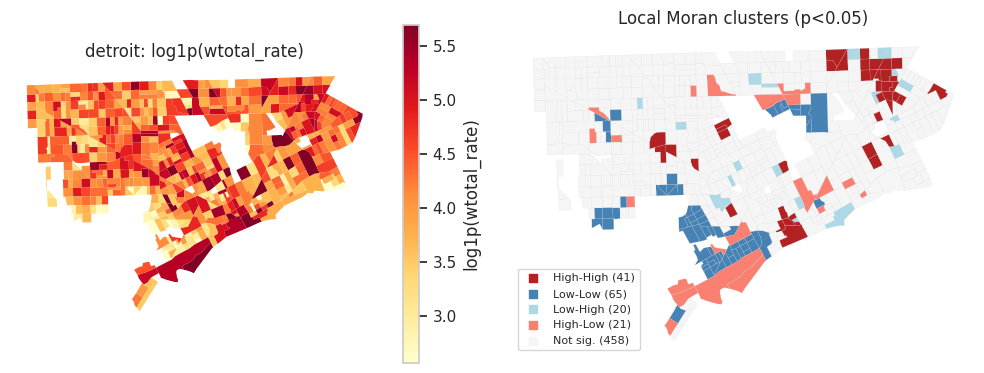

In [11]:
lisa_city = "detroit"
lisa_target = "wtotal_rate"
plot_city_crime(geo[(lisa_city,lisa_target)], lisa_target, lisa_city)

### Local Moran (LISA): how significance is tested

**Local statistic.** Standardize log-rate within the city, $z_i = \dfrac{x_i - \bar{x}}{s}$. For block group $i$ with neighbour set $N_i$ ($k = 8$ nearest):

$$
\text{lag}_i = \frac{1}{k}\sum_{j \in N_i} z_j, \qquad I_i = z_i \cdot \text{lag}_i
$$

Global Moran's I is (up to scaling) the average of the $I_i$.

#### 1. Conditional permutation: what "shuffled 999 times" means

The map stays fixed; the crime values move. For block group $i$:

- Keep $z_i$ where it is.
- Keep its 8 neighbour **slots** where they are.
- Fill those slots with values drawn at random from the city's other $n-1$ block groups.
- Compute $I_i^{(r)}$ for that draw.
- Repeat for $r = 1, \dots, R$ with $R = 999$.

Each draw is the same set of crime values in a random arrangement, which is what the city would look like if location didn't matter. Compare the real $I_i$ with the 999 simulated ones:

$$
p_i = \frac{\#\{\, r : I_i^{(r)} \text{ at least as extreme as } I_i \,\} + 1}{R + 1}
$$

The smallest possible value is $p = 1/1000 = 0.001$.

#### 2. Worked example

Block group with $z_i = +2$ (well above the city mean), real neighbour average $\text{lag}_i = +1.5$.

- **Random draws:** each simulated lag averages 8 random values, so its spread shrinks: $\text{sd}(\text{lag}^{(r)}) \approx 1/\sqrt{8} \approx 0.35$. Nearly all fall between about $-0.7$ and $+0.7$.
- **Count:** how many of the 999 are $\ge +1.5$? About 0.
- **p-value:** $p = (0+1)/1000 = 0.001$. It's significant: **High-High**.

If the real lag were only $+0.3$, about 200 of the 999 would be $\ge +0.3$, so $p \approx 0.2$: **Not sig.** Random neighbours land near $+0.3$ all the time.

#### 3. How the direction is chosen

esda tests $I_i$ in whichever tail the real value falls, and counts only that tail:

- Real $I_i$ high: count $I_i^{(r)} \ge I_i$.
- Real $I_i$ low: count $I_i^{(r)} \le I_i$.

In plain terms: how often do random neighbours look at least this similar (or at least this dissimilar) to block group $i$?

#### 4. Buckets (significant block groups only)

| Bucket | $z_i$ | $\text{lag}_i$ | Meaning |
|---|---|---|---|
| High-High | $+$ | $+$ | Hotspot: part of a high-crime area |
| Low-Low | $-$ | $-$ | Coldspot: part of a low-crime area |
| High-Low | $+$ | $-$ | Spike: busy location in a quiet area (mall, transit hub) |
| Low-High | $-$ | $+$ | Hole: quiet location inside a hotspot (park, cemetery) |

#### 5. Multiple testing: read regions, not single block groups

Each test at $\alpha = 0.05$ has a 5% false-alarm rate. With one test per block group, the expected number of chance labels under pure randomness is

$$
E[\text{false labels}] = \alpha \cdot n = 0.05 \times 2{,}159 \approx 108 \quad \text{(Chicago)}
$$

So any **single** labelled block group could be noise; a lone High-Low could be one of those ~108. A contiguous region of 50 High-High block groups is different, because random false alarms scatter rather than form blocks.

To be stricter, use $\alpha = 0.01$ (about 22 chance labels for Chicago), or a false-discovery-rate cutoff: `from esda import fdr; alpha = fdr(lisa.p_sim, 0.05)`.

In [12]:
from regression_modelling.constants import PROPERTY_LAG_COLS

FAMILIES = {
    "demographic": DEMOGRAPHIC_PREDICTORS,
    "property":    PROPERTY_PREDICTORS + PROPERTY_LAG_COLS,
    "transit":     TRANSIT_PREDICTORS + ACS_TRANSIT_PREDICTORS,
    "imagery":     IMAGERY_PREDICTORS,
    "roadway":     ROADWAY_PREDICTORS,
}
# rows sorted by crime level, so predictor gradients can be read against the target
city_order = pool.groupby("city")["wprop_rate"].median().sort_values(ascending=False).index

def city_medians(df, cols, order):
    # astype(float): transit_stop_count is nullable Int64, which seaborn can't plot
    return df.groupby("city")[cols].median().loc[order].astype(float)

def median_heatmap(med, title):
    z = ((med - med.mean()) / med.std()).fillna(0)     # zero-variance columns -> 0, not blank
    fig, ax = plt.subplots(figsize=(1.3 * med.shape[1] + 3, 0.4 * med.shape[0] + 2))
    sns.heatmap(z, annot=med, fmt=".3g", cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5,
                cbar_kws={"label": "z across cities", "shrink": .6}, annot_kws={"size": 8}, ax=ax)
    ax.set_title(title); ax.set_ylabel("city (sorted by median wprop_rate)")
    plt.xticks(rotation=35, ha="right"); fig.tight_layout(); plt.show()

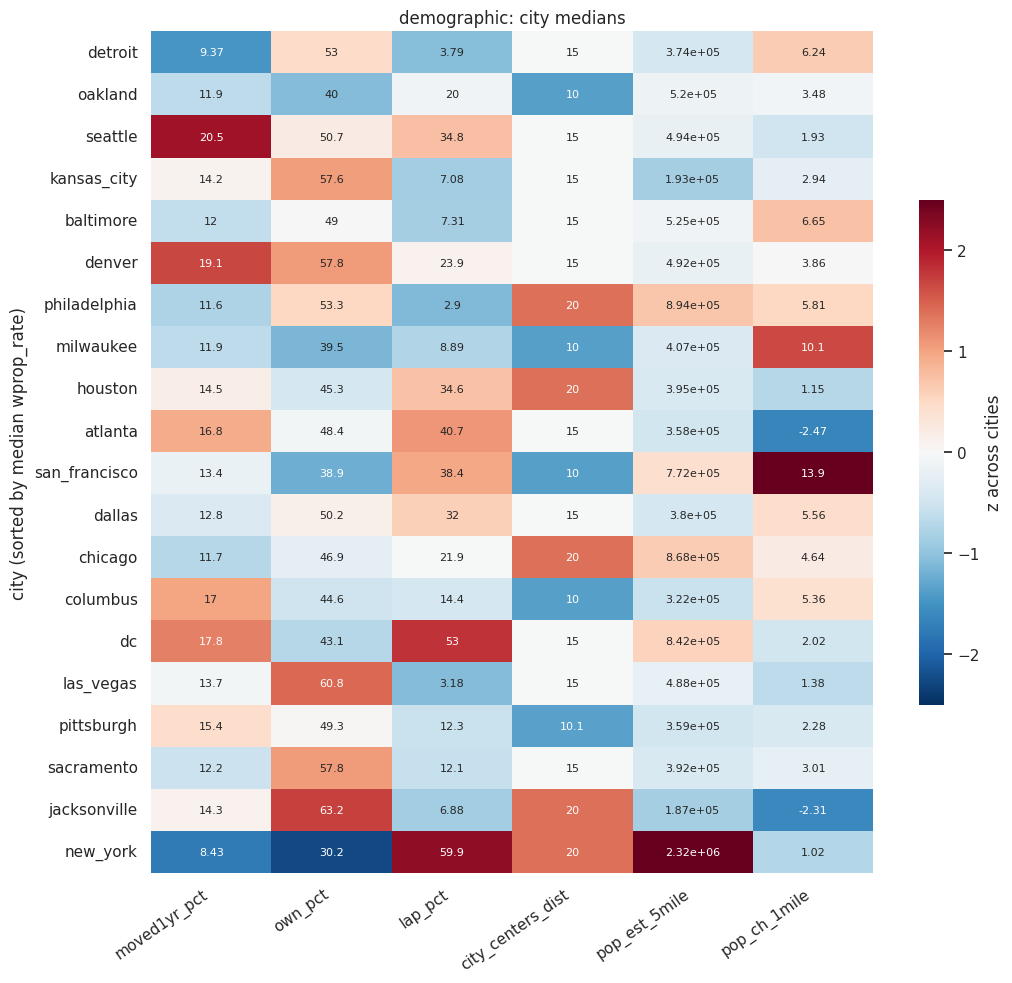

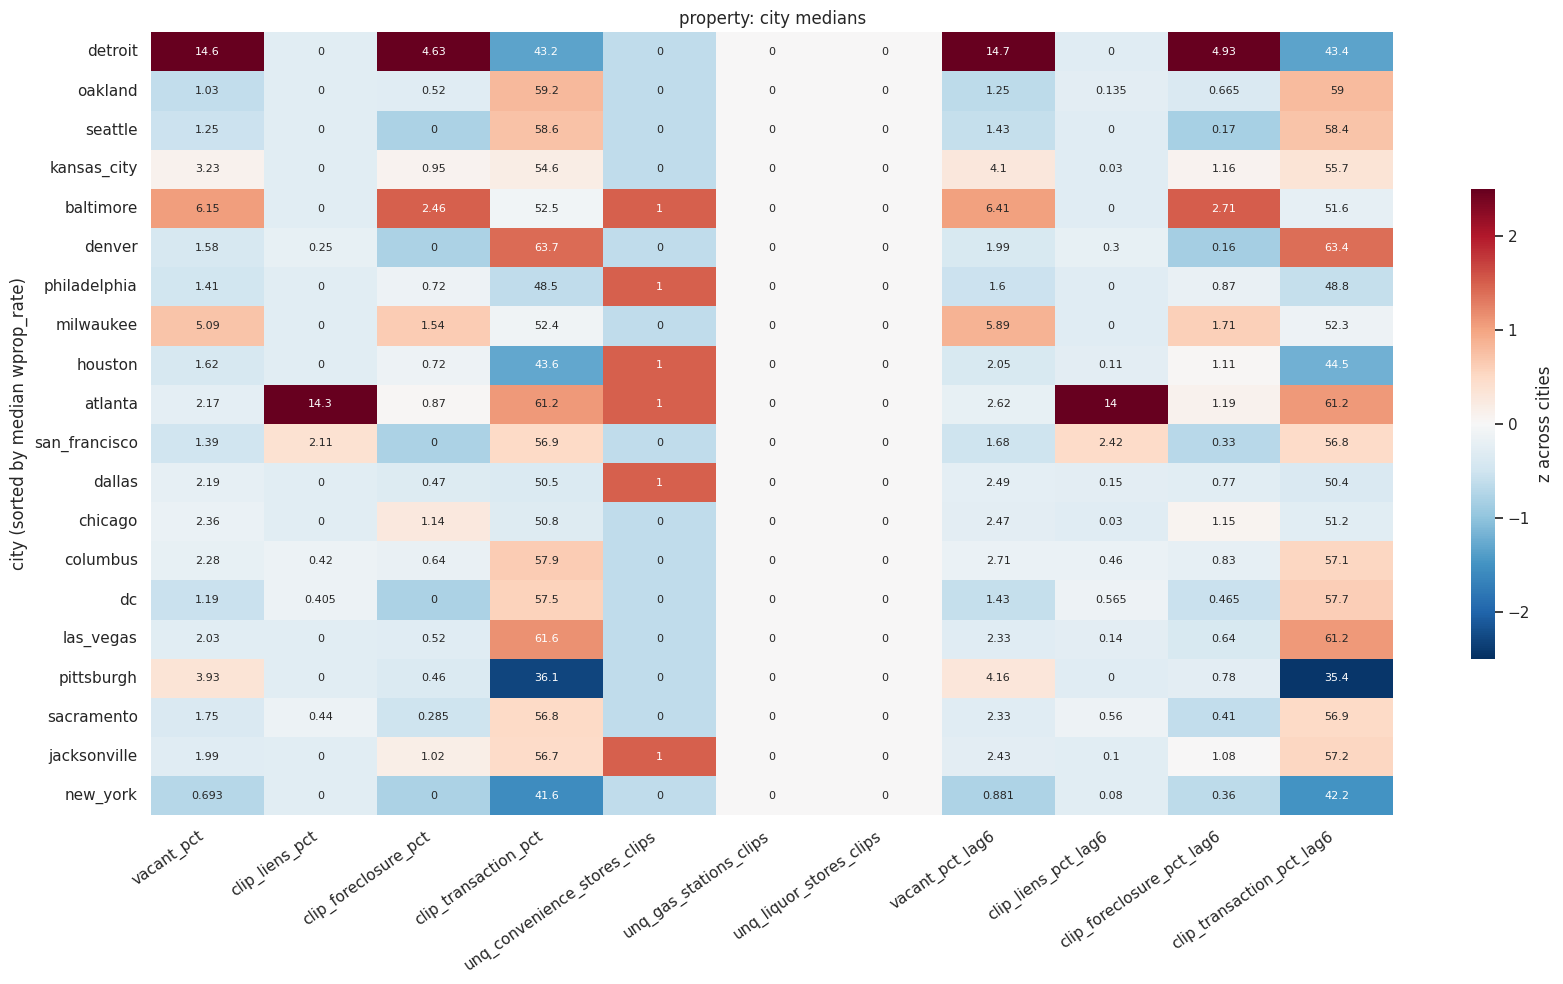

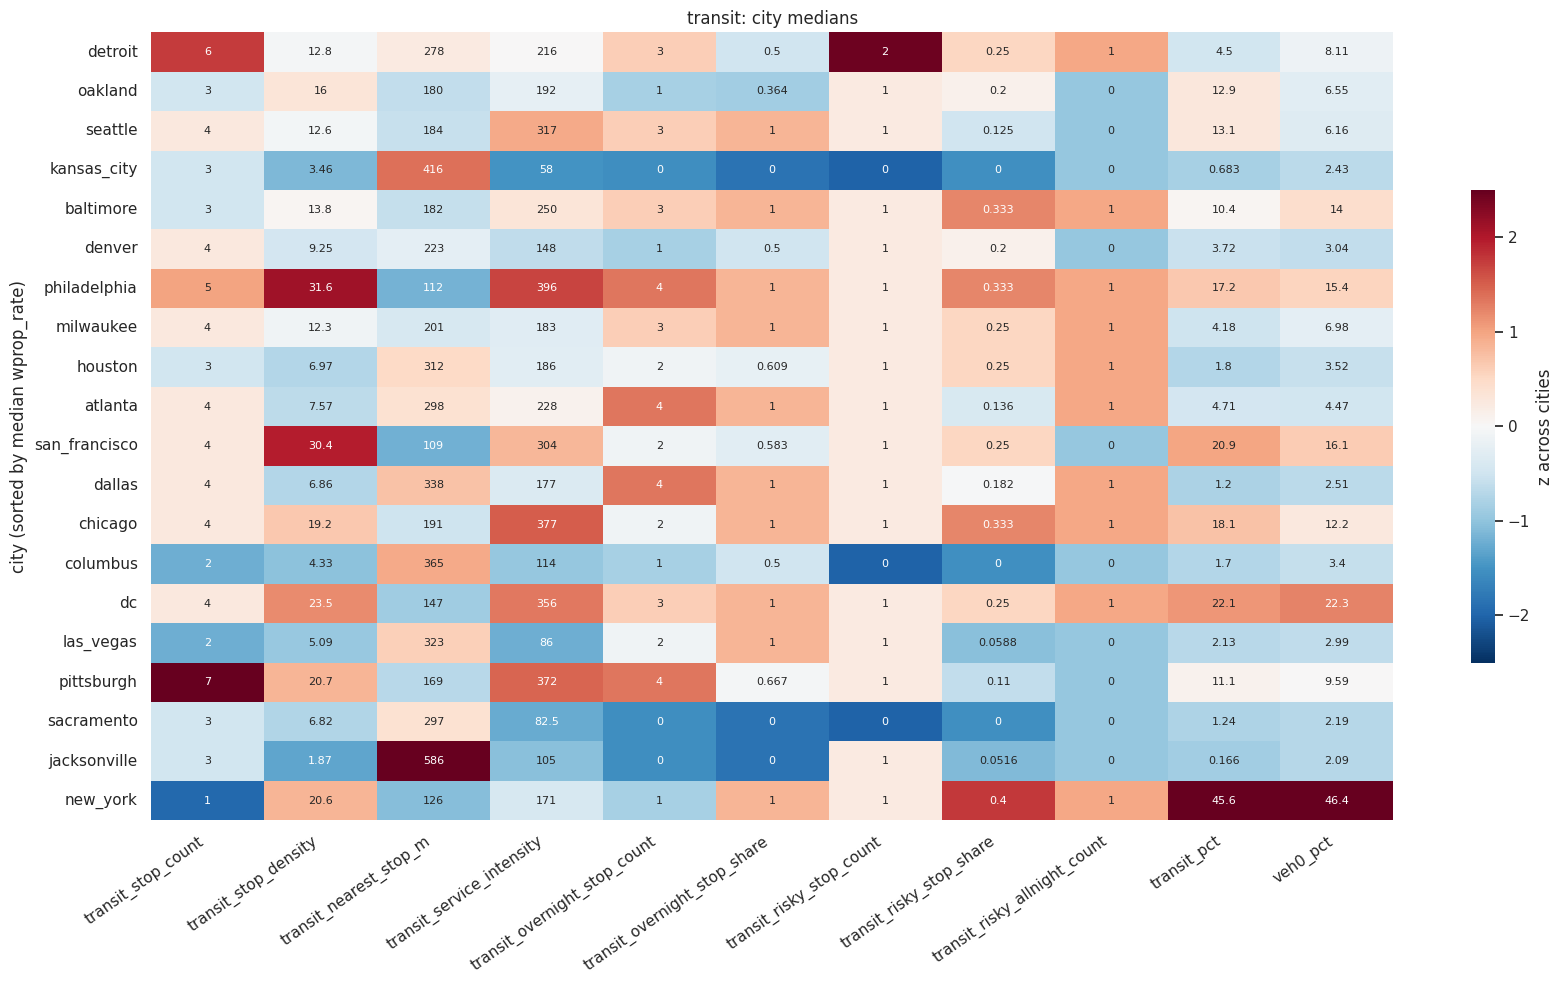

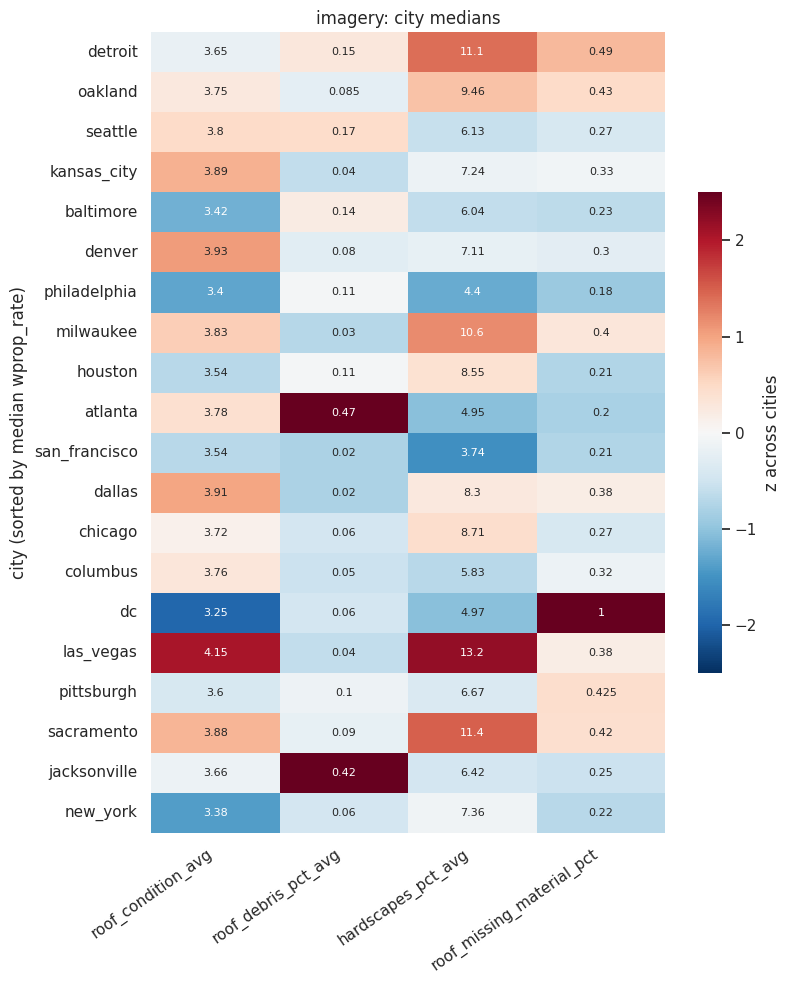

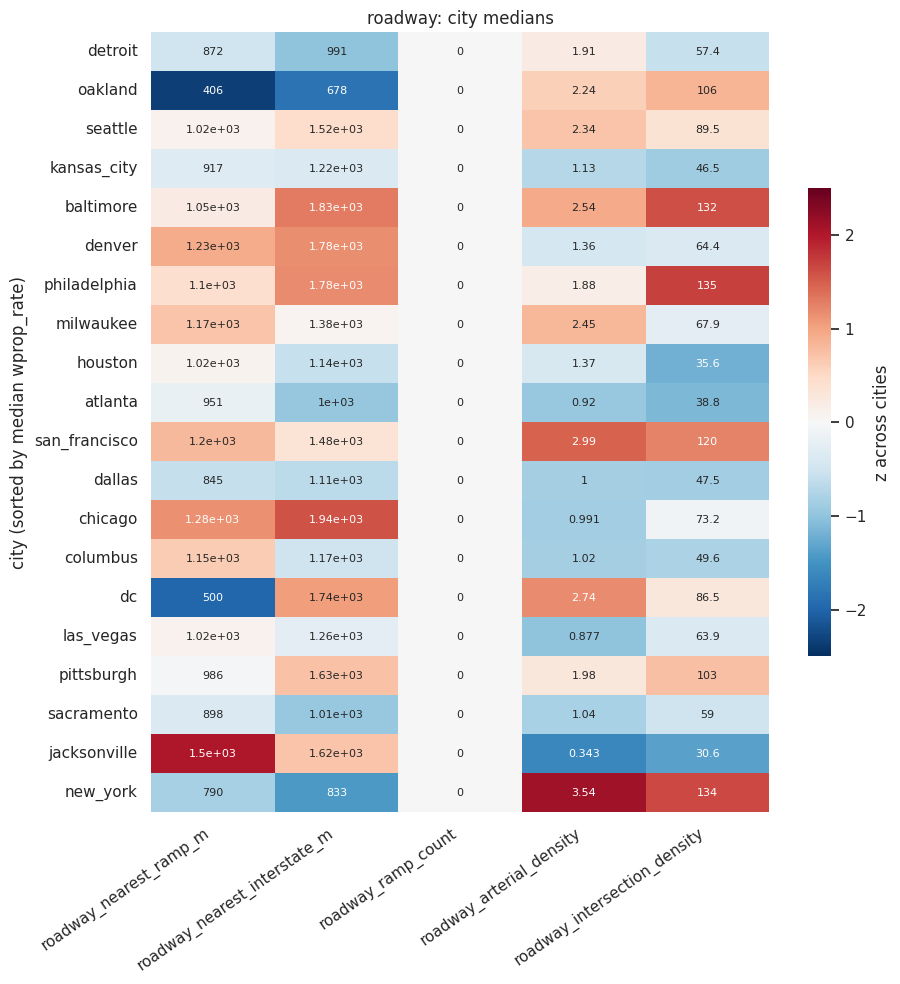

In [13]:
# One heatmap per family
for fam, cols in FAMILIES.items():
    median_heatmap(city_medians(pool, cols, city_order), f"{fam}: city medians")

### Feature checks (2026-09-29)

#### 1. `city_centers_dist`: imported, not computed, and a coarse band

- **Source:** an existing GCS file, `demographic/proximity/bg_poi_walk_drive_counts.sav`, keyed to 2010 block groups. `features._add_distance_to_center` converts it to 2020 block groups with a population-weighted average. We never compute a distance ourselves.
- **Values are bands:** 1, 5, 10, 15, 20, 30, 50. In-between values (11, 22, …) are artifacts of averaging bands across the 2010→2020 conversion.
- **Weak proxy for true distance to downtown** (Spearman, band vs centroid-to-downtown miles):

  | City | Spearman |
  |---|---|
  | Chicago | 0.46 |
  | DC | 0.65 |
  | Houston | 0.49 |
  | NYC | **0.14** |

- NYC block groups 0.1 miles from Times Square sit in the 15 band. DC's minimum is 5, yet the whole district is about 6 miles across.
- It probably encodes something like a drive-distance band to a "city center" point, not distance to *this* city's downtown. The repo has no definition for it.
- **Recommendation:** compute our own continuous distance to the downtown centre (NYC may need more than one centre).

#### 2. Property shares (2020–2024 window)

- **`clip_transaction_pct`**: properties with **any** recorded deed (all deed categories) as a share of all properties in the block group:

$$
\text{clip\_transaction\_pct} = 100 \times \frac{\#\,\text{clips with any deed}}{\#\,\text{clips in BG}}
$$

- **`clip_foreclosure_pct`**: properties with a foreclosure deed (`deedcattyp = 'U'`) as a share of properties that transacted:

$$
\text{clip\_foreclosure\_pct} = 100 \times \frac{\#\,\text{clips with a foreclosure deed}}{\#\,\text{clips with any deed}}
$$

  Block groups with no transactions come out `NULL` and are zero-filled.

- **Flags:**
  - Transaction medians of 36–64% over 5 years look high for arm's-length sales. "All deed categories" likely includes quitclaims and family transfers.
  - Foreclosure is 0 for more than 50% of block groups in NYC, Seattle, Denver, SF and DC. That's more likely a difference in how foreclosures are recorded between states than real distress.

### Transit × risky-facility features (H1 / H3)

A stop is **risky** if it lies within **150 m** (`RISKY_RADIUS_M`) of a convenience or liquor store. The ATM layer was never pulled, so ATMs aren't included. Flags are set **per stop** first, then aggregated to the block group, so a block group isn't flagged just because a daytime risky stop and a separate all-night stop happen to share it.

Per stop $s$ in block group $b$:

$$
\text{near\_risky}_s = \mathbb{1}\big[\exists\ \text{store within } 150\text{ m of } s\big], \qquad
\text{overnight}_s = \mathbb{1}\big[\text{first dep} < 05{:}00 \ \lor\ \text{last dep} \ge 24{:}00\big]
$$

(`overnight` is measured on the representative service date, `2025-06-04`.)

| Feature | Definition | Hypothesis |
|---|---|---|
| `transit_risky_stop_count` | $\sum_{s \in b} \text{near\_risky}_s$: number of stops near a risky store | H1 |
| `transit_risky_stop_share` | $\frac{1}{n_b}\sum_{s \in b} \text{near\_risky}_s$: share of the block group's stops that are risky (0 if no stops) | H1 |
| `transit_risky_allnight_count` | $\sum_{s \in b} \text{near\_risky}_s \cdot \text{overnight}_s$: stops that are risky **and** have overnight service | H3 |

Notes:
- "All-night" really means *any* departure between 00:00 and 05:00, not continuous service through the night.
- `risky_stop_count` is a subset of `transit_stop_count`, so expect high correlation; `risky_stop_share` is the cleaner signal.
- Model form: counts are `log1p` → `*_log`; the share stays raw in $[0,1]$.

#### IDEA: Adding a spatial angle to POI (store) features

The current `unq_*_clips` count only store parcels **inside** the block group polygon, which is usually 0 or 1. Two ways to capture neighbourhood exposure:

| Option | How | Pros | Cons |
|---|---|---|---|
| **A. KNN(6) lag** | Stores in the block group plus its 6 nearest neighbours (same pooled approach as the property `_lag6` columns) | Consistent with the property lags | Still depends on block group boundaries; needs a BigQuery SQL change |
| **B. Radius count** | Stores within 400 m or 800 m of the block group centroid, from the cached point layers (`data/interim/transit/facilities/`) | Doesn't depend on boundaries; closer to how crime spills over; runs locally | Gas station points aren't cached yet (one BigQuery pull) |

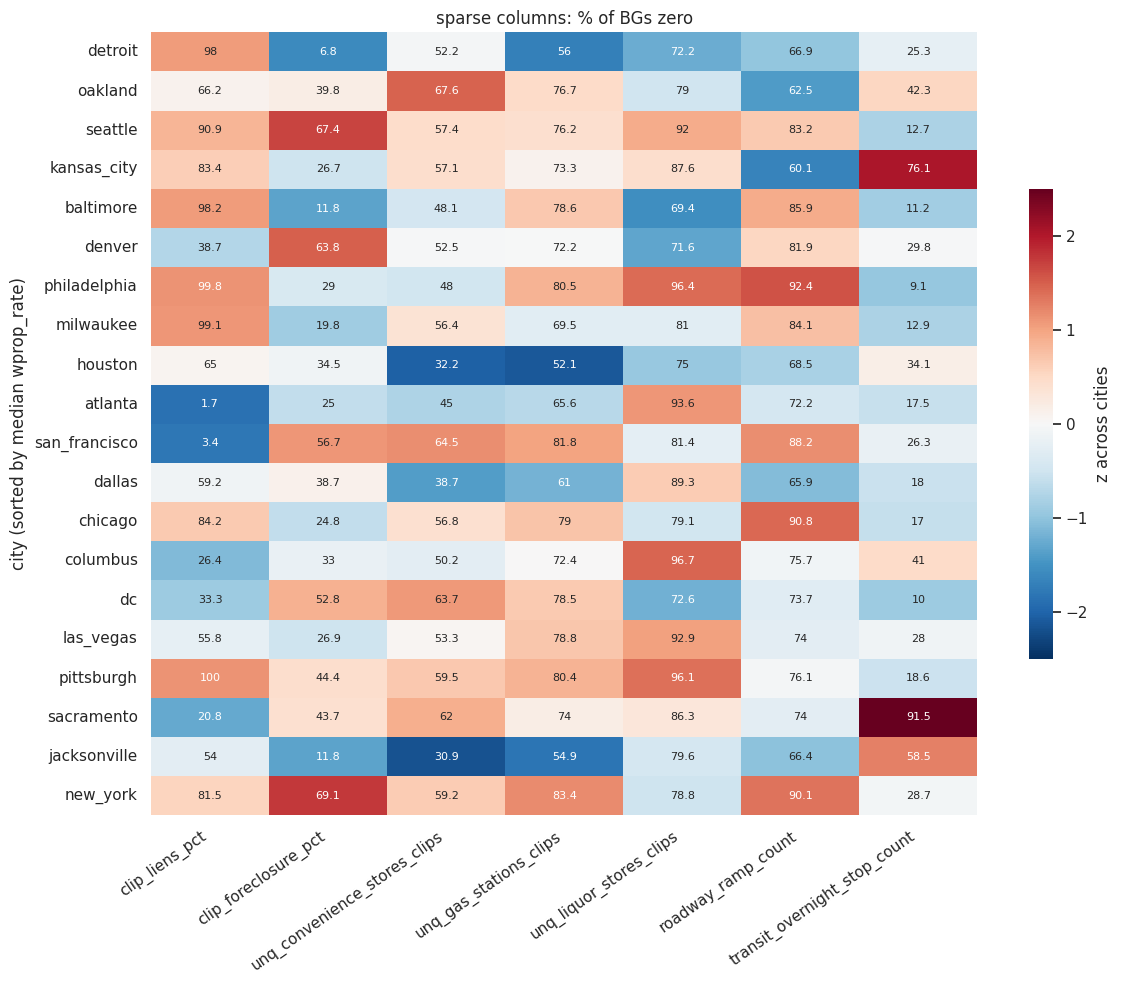

In [14]:
SPARSE = ["clip_liens_pct", "clip_foreclosure_pct", "unq_convenience_stores_clips",
          "unq_gas_stations_clips", "unq_liquor_stores_clips", "roadway_ramp_count",
          "transit_overnight_stop_count"]

pct_zero = (pool.groupby("city")[SPARSE]
          .agg(lambda s: (s== 0).mean() * 100)
          .loc[city_order].astype(float).round(1))
median_heatmap(pct_zero, "sparse columns: % of BGs zero")

In [15]:
# Check zero fill and median filled columns 
feats = assemble_features(refresh=False)          # national BG matrix, BEFORE imputation
FILLED = [c for c in ZERO_FILL + MEDIAN_FILL if c in feats.columns]

raw_feats = pool[["geoid", "city"]].merge(feats[["geoid"] + FILLED], on="geoid", how="left")
pct_na_prefill = (raw_feats.groupby("city")[FILLED]
                           .apply(lambda d: d.isna().mean() * 100)
                           .loc[city_order].round(1))
pct_na_prefill.loc[:, pct_na_prefill.max() > 0]     # only columns that ever had gaps

,vacant_pct,clip_liens_pct,clip_foreclosure_pct,clip_transaction_pct,vacant_pct_lag6,clip_liens_pct_lag6,clip_foreclosure_pct_lag6,clip_transaction_pct_lag6,unq_convenience_stores_clips,unq_gas_stations_clips,unq_liquor_stores_clips
city,,,,,,,,,,,
detroit,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
oakland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
seattle,0.2,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
kansas_city,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
baltimore,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
denver,0.2,0.2,0.4,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2
philadelphia,0.0,0.2,1.0,0.2,0.0,0.2,0.2,0.2,0.2,0.2,0.2
milwaukee,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
houston,0.3,0.4,1.1,0.4,0.3,0.4,0.4,0.4,0.4,0.4,0.4


In [16]:
#  missing values after building the tables (never filled, so these rows get dropped at fit time)
CANDIDATES = [c for fam in FAMILIES.values() for c in fam]
pct_na_table = (pool.groupby("city")[CANDIDATES]
                    .apply(lambda d: d.isna().mean() * 100)
                    .loc[city_order].round(1))
pct_na_table.loc[:, pct_na_table.max() > 0]

,roof_condition_avg,roof_debris_pct_avg,hardscapes_pct_avg,roof_missing_material_pct
city,,,,
detroit,0.0,0.0,0.0,0.8
oakland,0.0,0.0,0.0,1.7
seattle,0.0,0.0,0.0,3.9
kansas_city,0.0,0.0,0.0,5.1
baltimore,0.0,0.0,0.0,2.3
denver,0.2,0.2,0.2,8.3
philadelphia,0.0,0.0,0.0,1.8
milwaukee,0.0,0.0,0.0,3.5
houston,0.3,0.3,0.3,5.6


In [17]:
# coverage
by_city = pool.groupby("city")
coverage = pd.DataFrame({
    "has_transit_pct":   by_city["transit_has_transit"].mean() * 100,
    "imagery_pct":       by_city["roof_condition_avg"].apply(lambda s: s.notna().mean()) * 100,
    "zero_property_pct": by_city["property_count"].apply(lambda s: (s == 0).mean()) * 100,
    "zero_violent_pct":  pool[pool["in_wtotal"]].groupby("city")["violent_count"]
                             .apply(lambda s: (s == 0).mean()) * 100,
}).loc[city_order].round(1)
coverage

,has_transit_pct,imagery_pct,zero_property_pct,zero_violent_pct
city,,,,
detroit,96.4,100.0,0.2,1.0
oakland,92.6,100.0,0.0,15.1
seattle,93.1,100.0,0.2,NaN
kansas_city,68.0,100.0,0.2,8.3
baltimore,90.6,100.0,0.0,3.7
denver,91.5,99.8,0.5,NaN
philadelphia,94.6,100.0,0.2,5.9
milwaukee,93.1,100.0,0.4,6.9
houston,78.5,99.7,3.1,8.0


In [18]:
MODEL_FORM = {
    "demographic": DEMOGRAPHIC_MODEL_PREDICTORS,
    "property":    PROPERTY_MODEL_PREDICTORS,
    "transit":     TRANSIT_MODEL_PREDICTORS + ["transit_risky_stop_count_log",
                   "transit_risky_stop_share", "transit_risky_allnight_count_log"],
    "acs_transit": ACS_TRANSIT_MODEL_PREDICTORS,
    "imagery":     IMAGERY_PREDICTORS,
    "roadway":     ROADWAY_PREDICTORS,          # no model form yet -> log1p below
}
mf = pool.copy()
mf[ROADWAY_PREDICTORS] = np.log1p(mf[ROADWAY_PREDICTORS])
mf["log1p_wprop_rate"] = np.log1p(mf["wprop_rate"])

In [19]:
def between_share(df, col, group="city"):
    x = df[[group, col]].dropna()
    grand = x[col].mean()
    g = x.groupby(group)[col]
    ss_between = (g.size() * (g.mean() - grand) ** 2).sum()
    ss_total = ((x[col] - grand) ** 2).sum()
    return ss_between / ss_total

rows = [{"family": fam, "predictor": c, "between_share": between_share(mf, c)}
        for fam, cols in MODEL_FORM.items() for c in cols]
rows.append({"family": "target", "predictor": "log1p_wprop_rate",
             "between_share": between_share(mf, "log1p_wprop_rate")})
bw = pd.DataFrame(rows).sort_values("between_share", ascending=False).round(3)
bw

,family,predictor,between_share
14,property,clip_liens_pct_lag6_log,0.843
4,demographic,pop_est_5mile_log,0.817
24,acs_transit,transit_pct_log,0.725
7,property,clip_liens_pct_log,0.710
25,acs_transit,veh0_pct_log,0.455
13,property,vacant_pct_lag6_log,0.428
26,imagery,roof_condition_avg,0.423
34,roadway,roadway_intersection_density,0.421
15,property,clip_foreclosure_pct_lag6_log,0.321
6,property,vacant_pct_log,0.306


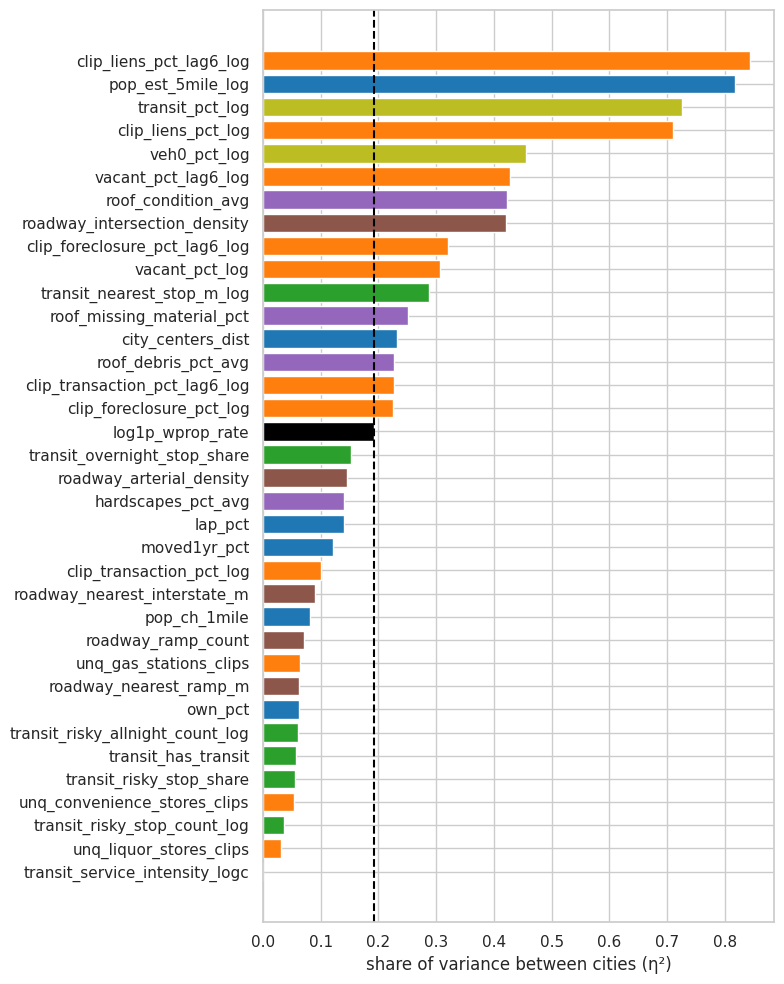

In [20]:
FAMILY_COLORS = {"demographic": "tab:blue", "property": "tab:orange", "transit": "tab:green",
                 "acs_transit": "tab:olive", "imagery": "tab:purple", "roadway": "tab:brown",
                 "target": "black"}
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(bw["predictor"], bw["between_share"], color=bw["family"].map(FAMILY_COLORS))
ax.axvline(bw.loc[bw["family"] == "target", "between_share"].iloc[0], ls="--", color="black")
ax.invert_yaxis(); ax.set_xlabel("share of variance between cities (η²)")
fig.tight_layout(); plt.show()